<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_PR_pr_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
data = pd.read_csv("Mall_Customers.csv")
data.head()
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns)
print("\nInformation:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
encoder = LabelEncoder()
data["Gender"] = encoder.fit_transform(data["Gender"])
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
X = data[['Age',
          'Annual Income (k$)',
          'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

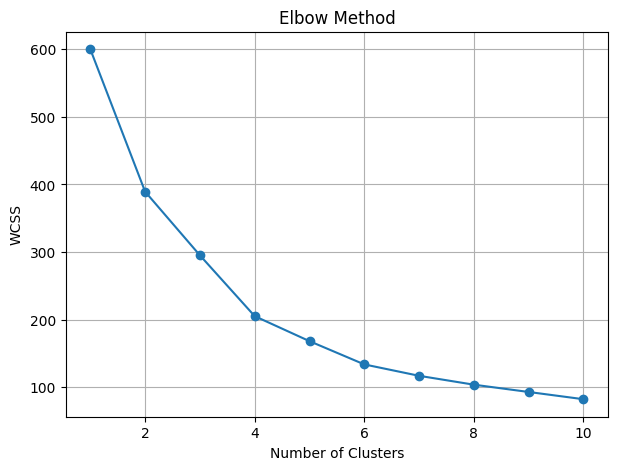

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(7,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5,
                random_state=42,
                n_init=10)
clusters = kmeans.fit_predict(X_scaled)
data["KMeans_Cluster"] = clusters
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,1,19,15,39,1
1,2,1,21,15,81,1
2,3,0,20,16,6,0
3,4,0,23,16,77,1
4,5,0,31,17,40,1


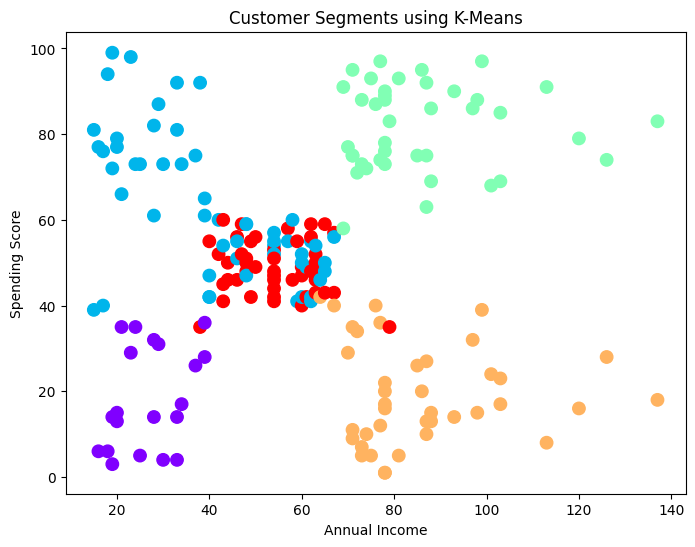

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=data['KMeans_Cluster'],
            cmap='rainbow',
            s=80)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments using K-Means")
plt.show()

In [ ]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.41664341513732767


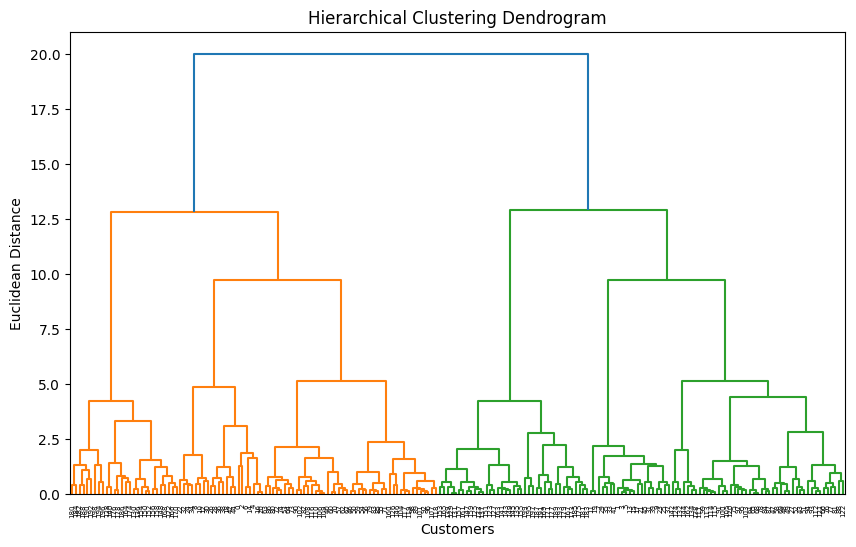

In [ ]:
linked = linkage(X_scaled,
                 method='ward')
plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)
hc_clusters = hc.fit_predict(X_scaled)
data["Hierarchical_Cluster"] = hc_clusters

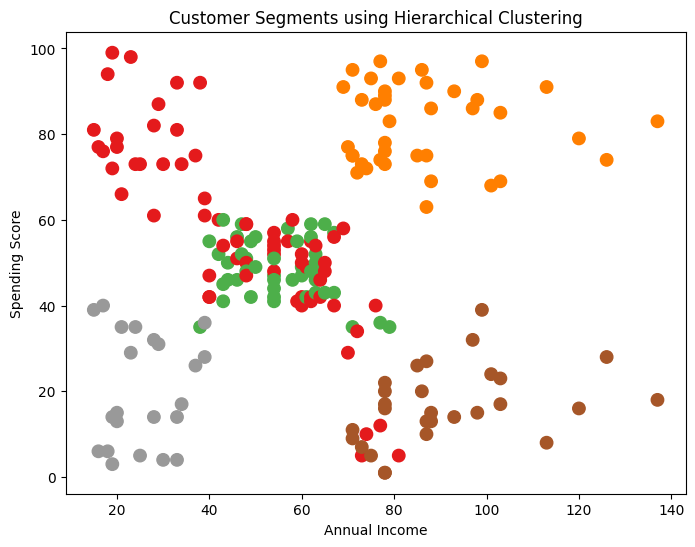

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=data['Hierarchical_Cluster'],
            cmap='Set1',
            s=80)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments using Hierarchical Clustering")
plt.show()

In [ ]:
print("K-Means Cluster Counts")
print(data["KMeans_Cluster"].value_counts())
print("\nHierarchical Cluster Counts")
print(data["Hierarchical_Cluster"].value_counts())
cluster_summary = data.groupby("KMeans_Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()
print(cluster_summary)
data.to_csv("Customer_Segmentation_Result.csv", index=False)
print("Result Saved Successfully")

K-Means Cluster Counts
KMeans_Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

Hierarchical Cluster Counts
Hierarchical_Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64
                      Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                       
0               46.250000           26.750000               18.350000
1               25.185185           41.092593               62.240741
2               32.875000           86.100000               81.525000
3               39.871795           86.102564               19.358974
4               55.638298           54.382979               48.851064
Result Saved Successfully
